In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from itertools import islice
import io
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [2]:
def reading(file_path, start_line, num_entries, head_names):
    #open the file to read the data from the frame
    with open(file_path, "r") as f:
        #header block of the data that needs to be iterated through
        header_block = islice(f, start_line-1, num_entries + start_line)
        #new datafram to store the read data
        new_df = pd.read_csv(io.StringIO("".join(header_block)),
                             sep='\s+',
                             header=None,
                             names=head_names)

    #returning the new dataframe    
    return new_df



In [3]:
hed_file = "c:\WINDLAB_SUMMER\ee1\ADW100o100D016a1950\ADW100o100D016a1950.hed"
df_asc = pd.read_csv('C:\WINDLAB_SUMMER\ADW100o100D016a1950\ADW100o100D016a1950.asc', sep='\s+', header=None)
start_line = 344
num_entries = 504
head_names = ['Tap_No', 'Face_No', 'X', 'Y', 'Z']
tap_df = reading(hed_file, start_line, num_entries, head_names)
print(tap_df)


     Tap_No  Face_No      X      Y      Z
0     104.0      3.0  34.36  125.0   4.00
1     105.0      3.0  34.36  125.0   9.00
2     106.0      3.0  34.36  125.0  14.00
3     107.0      3.0  34.36  125.0  16.64
4     108.0      3.0  28.71  125.0  14.00
..      ...      ...    ...    ...    ...
499  4015.0      3.0  68.21  125.0   4.00
500  4016.0      3.0  73.86  125.0   4.00
501  4101.0      3.0  79.50  125.0   3.17
502  4210.0      0.0  41.00   62.5   0.00
503  4211.0      0.0  39.00   62.5   0.00

[504 rows x 5 columns]


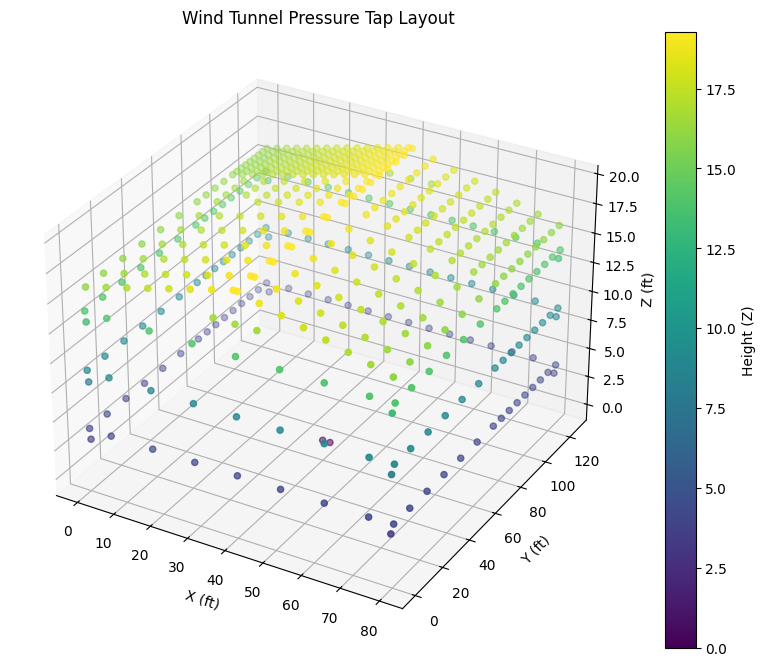

In [4]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = tap_df['X']
y = tap_df['Y']
z = tap_df['Z']
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=20)

ax.set_xlabel('X (ft)')
ax.set_ylabel('Y (ft)')
ax.set_zlabel('Z (ft)')
ax.set_title('Wind Tunnel Pressure Tap Layout')

plt.colorbar(scatter, label='Height (Z)')

plt.show()


In [5]:
#this takes the wind speed profile table and puts it into a dataframe
start_line_speed = 217
num_entries_speed = 42
head_names_speed = ['H', 'V Ratio','Iu', 'Iv', 'Iw']


wind_speed_df = reading(hed_file, start_line_speed, num_entries_speed, head_names_speed)
print(wind_speed_df.head())

      H  V Ratio      Iu   Iv   Iw
0  1.27    0.453  24.313  0.0  0.0
1  1.27    0.451  23.589  0.0  0.0
2  3.05    0.553  20.436  0.0  0.0
3  3.66    0.557  19.256  0.0  0.0
4  4.88    0.590  18.999  0.0  0.0


In [6]:
#building corners and frame with lines dataframe as well as python imaging
#using these 2 dfs together will help to create the final image of the building (next kernel)

#using reading function to created dataframe of corners
start_line_corners = 303
num_entires_corners = 10
head_names_corners = ['X', 'Y', 'Z']
corners_df = reading(hed_file, start_line_corners, num_entires_corners, head_names_corners)
print(corners_df)
#using reading function to create dataframe of the line to create the frame of the building
start_line_frame = 321
num_entries_frame = 15
head_names_frames = ['Start', 'End']
frames_df = reading(hed_file, start_line_frame,num_entries_frame, head_names_frames)
print(frames_df)

#here we are creating the new 0 indexed frames dataframe so that it can match the 0'd corner coordinates
frames_df['Start_0'] = frames_df['Start'] - 1
frames_df['End_0'] = frames_df['End'] - 1
print(frames_df)

frames_0_df = frames_df.drop(columns=['Start','End'])
print(frames_0_df)


      X      Y       Z
0   0.0    0.0   0.000
1   0.0  125.0   0.000
2  80.0  125.0   0.000
3  80.0    0.0   0.000
4   0.0    0.0  16.000
5   0.0  125.0  16.000
6  40.0  125.0  19.333
7  80.0  125.0  16.000
8  80.0    0.0  16.000
9  40.0    0.0  19.333
    Start  End
0       1    2
1       1    5
2       1    4
3       2    6
4       2    3
5      10    5
6      10    9
7      10    7
8       8    7
9       8    9
10      8    3
11      4    9
12      4    3
13      5    6
14      6    7
    Start  End  Start_0  End_0
0       1    2        0      1
1       1    5        0      4
2       1    4        0      3
3       2    6        1      5
4       2    3        1      2
5      10    5        9      4
6      10    9        9      8
7      10    7        9      6
8       8    7        7      6
9       8    9        7      8
10      8    3        7      2
11      4    9        3      8
12      4    3        3      2
13      5    6        4      5
14      6    7        5      6
    Start_0

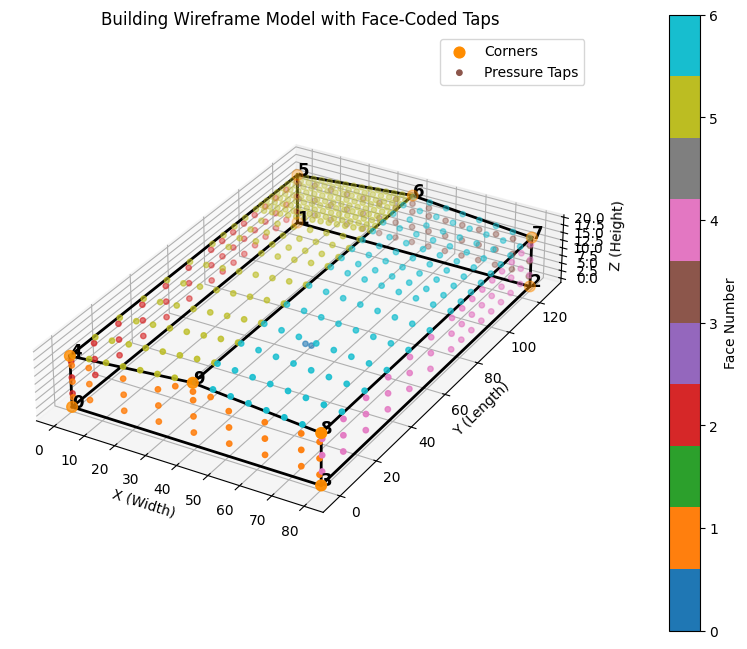

In [7]:
#this is where we will create the rendered building image using the corner and frame information given


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(corners_df['X'], corners_df['Y'], corners_df['Z'], 
           color='darkorange', s=60, label='Corners')

for _, line in frames_0_df.iterrows():
    start_id = int(line['Start_0'])
    end_id = int(line['End_0'])

    start_node = corners_df.iloc[start_id]
    end_node = corners_df.iloc[end_id]

    xs = [start_node['X'], end_node['X']]
    ys = [start_node['Y'], end_node['Y']]
    zs = [start_node['Z'], end_node['Z']]
    
    ax.plot(xs, ys, zs, color='black', linewidth=2)

for i, row in corners_df.iterrows():
    ax.text(row['X'], row['Y'], row['Z'], str(i), fontsize=12, fontweight='bold')


#now we superimpose the pressure taps on top of the building :))) 
scatter = ax.scatter(tap_df['X'], tap_df['Y'], tap_df['Z'], 
                     c=tap_df['Face_No'], 
                     cmap='tab10', 
                     s=15, 
                     label='Pressure Taps')

cbar = plt.colorbar(scatter, ax = ax, pad=0.1)
cbar.set_label('Face Number')


ax.set_xlabel('X (Width)')
ax.set_ylabel('Y (Length)')
ax.set_zlabel('Z (Height)')
ax.set_title('Building Wireframe Model with Face-Coded Taps')


ax.set_box_aspect([80, 125, 20]) 
ax.legend()
plt.show()

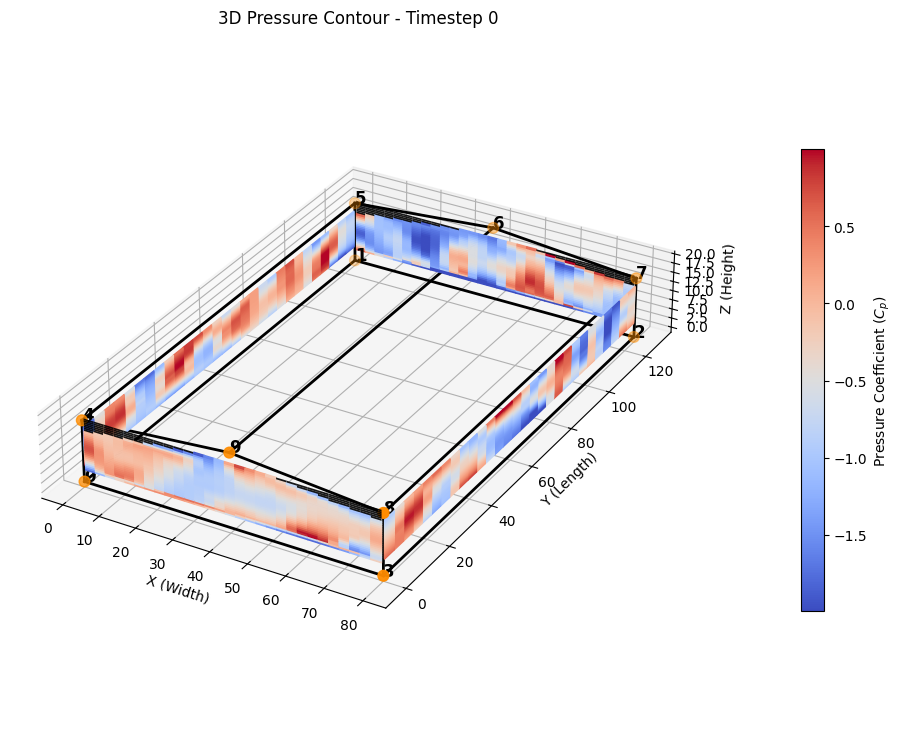

In [9]:
# --- CONFIGURATION ---
current_timestep = 0  # The row index from your .asc file
grid_res = 30j        # Resolution of the contour (30x30 per face)

# Pull the pressure row (Ensure df_asc is loaded)
# p_values = df_asc.iloc[current_timestep].values 
# For testing if df_asc isn't handy: 
p_values = np.random.uniform(-2, 1, size=len(tap_df)) 

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. DRAW WIREFRAME (Corners & Frames)
ax.scatter(corners_df['X'], corners_df['Y'], corners_df['Z'], 
           color='darkorange', s=60, label='Corners', zorder=5)

for _, line in frames_0_df.iterrows():
    start_node = corners_df.iloc[int(line['Start_0'])]
    end_node = corners_df.iloc[int(line['End_0'])]
    ax.plot([start_node['X'], end_node['X']], 
            [start_node['Y'], end_node['Y']], 
            [start_node['Z'], end_node['Z']], color='black', linewidth=2)

for i, row in corners_df.iterrows():
    ax.text(row['X'], row['Y'], row['Z'], str(i), fontsize=12, fontweight='bold')

# 2. GENERATE CONTOUR SURFACES (Face by Face)
p_min, p_max = p_values.min(), p_values.max()

for face in tap_df['Face_No'].unique():
    face_mask = tap_df['Face_No'] == face
    f_taps = tap_df[face_mask]
    
    if len(f_taps) < 3: # Need at least 3 points for interpolation
        continue
        
    f_pressures = p_values[face_mask]
    
    # Logic to determine plane and interpolate
    if f_taps['Z'].nunique() == 1: # XY Plane (Roof/Floor)
        xi, yi = np.mgrid[f_taps['X'].min():f_taps['X'].max():grid_res, 
                          f_taps['Y'].min():f_taps['Y'].max():grid_res]
        pi = griddata((f_taps['X'], f_taps['Y']), f_pressures, (xi, yi), method='cubic')
        
        z_val = f_taps['Z'].iloc[0]
        norm_p = (pi - p_min) / (p_max - p_min + 1e-9)
        ax.plot_surface(xi, yi, np.full_like(xi, z_val), facecolors=plt.cm.coolwarm(norm_p),
                        shade=False, rstride=1, cstride=1, antialiased=True, alpha=0.9)
                               
    elif f_taps['X'].nunique() == 1: # YZ Plane (Side Walls)
        yi, zi = np.mgrid[f_taps['Y'].min():f_taps['Y'].max():grid_res, 
                          f_taps['Z'].min():f_taps['Z'].max():grid_res]
        pi = griddata((f_taps['Y'], f_taps['Z']), f_pressures, (yi, zi), method='cubic')
        
        x_val = f_taps['X'].iloc[0]
        norm_p = (pi - p_min) / (p_max - p_min + 1e-9)
        ax.plot_surface(np.full_like(yi, x_val), yi, zi, facecolors=plt.cm.coolwarm(norm_p),
                        shade=False, rstride=1, cstride=1, antialiased=True, alpha=0.9)

    elif f_taps['Y'].nunique() == 1: # XZ Plane (Front/Back Walls)
        xi, zi = np.mgrid[f_taps['X'].min():f_taps['X'].max():grid_res, 
                          f_taps['Z'].min():f_taps['Z'].max():grid_res]
        pi = griddata((f_taps['X'], f_taps['Z']), f_pressures, (xi, zi), method='cubic')
        
        y_val = f_taps['Y'].iloc[0]
        norm_p = (pi - p_min) / (p_max - p_min + 1e-9)
        ax.plot_surface(xi, np.full_like(xi, y_val), zi, facecolors=plt.cm.coolwarm(norm_p),
                        shade=False, rstride=1, cstride=1, antialiased=True, alpha=0.9)

# 3. FORMATTING
mappable = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm)
mappable.set_array(p_values)
cbar = plt.colorbar(mappable, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Pressure Coefficient ($C_p$)')

ax.set_xlabel('X (Width)')
ax.set_ylabel('Y (Length)')
ax.set_zlabel('Z (Height)')
ax.set_box_aspect([80, 125, 20]) 
plt.title(f'3D Pressure Contour - Timestep {current_timestep}')

plt.show()

In [10]:
#Now We will do the flat coordinates and see what that gives as a test :D

start_line_corners_flat = 856
num_entries_corners_flat = 28
head_names_corners_flat = ['X', 'Y']
flat_corners_df = reading(hed_file, start_line_corners_flat, num_entries_corners_flat, head_names_corners_flat)
#print(flat_corners_df)

#using reading function to create dataframe of the line to create the frame of the building
start_line_frame_flat = 892
num_entries_frame_flat = 31
head_names_frames_flat = ['Start', 'End']
flat_frames_df = reading(hed_file, start_line_frame_flat,num_entries_frame_flat, head_names_frames_flat)
#print(flat_frames_df)

#here we are creating the new 0 indexed frames dataframe so that it can match the 0'd corner coordinates
flat_frames_df['Start_0'] = flat_frames_df['Start'] - 1
flat_frames_df['End_0'] = flat_frames_df['End'] - 1
#print(flat_frames_df)

flat_frames_0_df = flat_frames_df.drop(columns=['Start','End'])
#print(flat_frames_0_df)


start_line_tap_flat = 931
num_entries_tap_flat = 502
head_names_tap_flat = ['Tap no.', 'Face no.', 'X', "Y"]
flat_tap_df = reading(hed_file, start_line_tap_flat, num_entries_tap_flat, head_names_tap_flat)
print(flat_tap_df)

     Tap no.  Face no.      X       Y
0      104.0       3.0  34.36  148.33
1      105.0       3.0  34.36  143.33
2      106.0       3.0  34.36  138.33
3      107.0       3.0  34.36  135.69
4      108.0       3.0  28.71  138.33
..       ...       ...    ...     ...
497   4013.0       3.0  56.93  148.33
498   4014.0       3.0  62.57  148.33
499   4015.0       3.0  68.21  148.33
500   4016.0       3.0  73.86  148.33
501   4101.0       3.0  79.50  149.17

[502 rows x 4 columns]


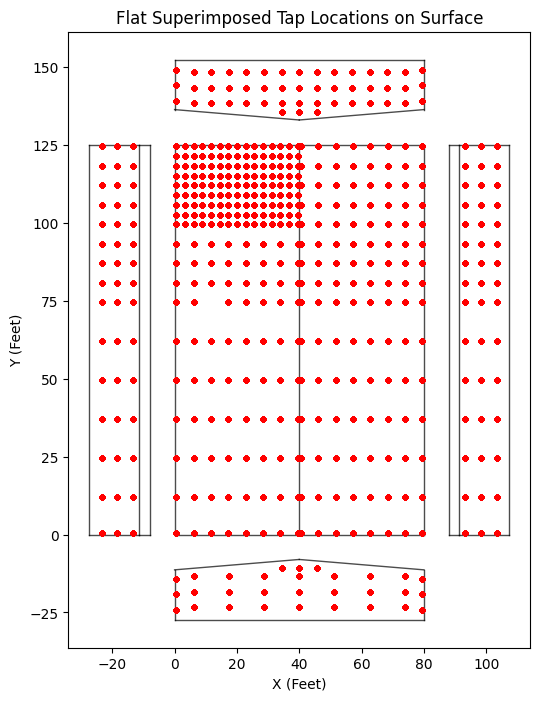

In [11]:
#this is where we will create the rendered building image using the corner and frame information given

plt.figure(figsize=(10, 8))

# Draw the lines connecting corners based on your pairs dataframe
for _, row in flat_frames_0_df.iterrows():
    idx1 = int(row.iloc[0]) 
    idx2 = int(row.iloc[1])

    
    # Pull the corresponding X and Y from your corners dataframe
    x_vals = [flat_corners_df.iloc[idx1]['X'], flat_corners_df.iloc[idx2]['X']]
    y_vals = [flat_corners_df.iloc[idx1]['Y'], flat_corners_df.iloc[idx2]['Y']]
    
    plt.plot(x_vals, y_vals, color='black', linewidth=1, alpha=0.7)


    plt.scatter(
    flat_tap_df['X'], 
    flat_tap_df['Y'], 
    color='red',          # Make them stand out
    s=10,                 # Size of the dots
    marker='o',           # Shape (circle)
    label='Pressure Taps',
    zorder=3              # Ensures points stay ON TOP of the lines
)
    


plt.title("Flat Superimposed Tap Locations on Surface")
plt.xlabel("X (Feet)")
plt.ylabel("Y (Feet)")
plt.gca().set_aspect('equal')
plt.show()



In [12]:

print(df_asc.head())

     0      1      2      3      4      5      6      7      8      9    ...  \
0  0.292  0.250  0.178 -0.060 -0.065 -0.078 -0.069 -0.045 -0.038 -0.062  ...   
1  0.292  0.262  0.188 -0.062 -0.077 -0.075 -0.056 -0.042 -0.052 -0.062  ...   
2  0.292  0.262  0.189 -0.083 -0.070 -0.064 -0.057 -0.038 -0.062 -0.062  ...   
3  0.292  0.286  0.189 -0.076 -0.068 -0.078 -0.078 -0.038 -0.062 -0.068  ...   
4  0.280  0.250  0.166 -0.063 -0.068 -0.075 -0.086 -0.067 -0.069 -0.080  ...   

     678    679    680    681    682    683    684    685    686    687  
0  0.944  0.006  0.935 -0.007  0.259  0.307  0.273  0.287  0.280  0.277  
1  0.947  0.010  0.942 -0.014  0.254  0.311  0.282  0.281  0.282  0.277  
2  0.952 -0.002  0.942 -0.014  0.242  0.303  0.288  0.300  0.293  0.276  
3  0.952  0.006  0.948 -0.014  0.243  0.300  0.297  0.287  0.290  0.267  
4  0.960  0.010  0.948 -0.014  0.259  0.295  0.273  0.276  0.269  0.287  

[5 rows x 688 columns]


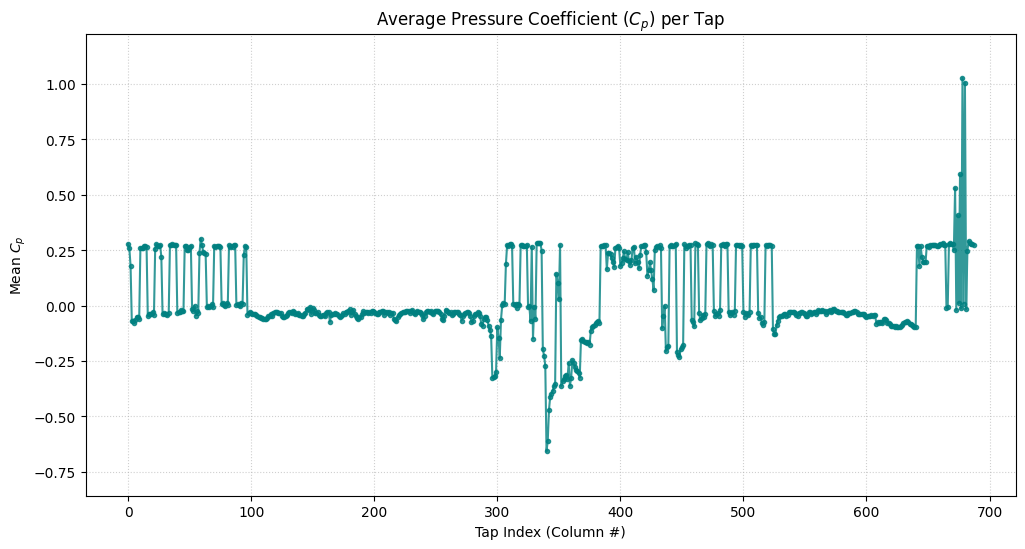

In [13]:
avg_pressures = df_asc.mean(axis=0)


plt.figure(figsize=(12,6))

plt.plot(avg_pressures.index, avg_pressures.values,color='teal', linewidth=1.5, marker='o', markersize=3, alpha=0.8)

# Labels and Title
plt.title('Average Pressure Coefficient ($C_p$) per Tap')
plt.xlabel('Tap Index (Column #)')
plt.ylabel('Mean $C_p$')
plt.grid(True, linestyle=':', alpha=0.6)

# Optional: Set y-axis limits to see suction better
plt.ylim(min(avg_pressures) - 0.2, max(avg_pressures) + 0.2)

plt.show()


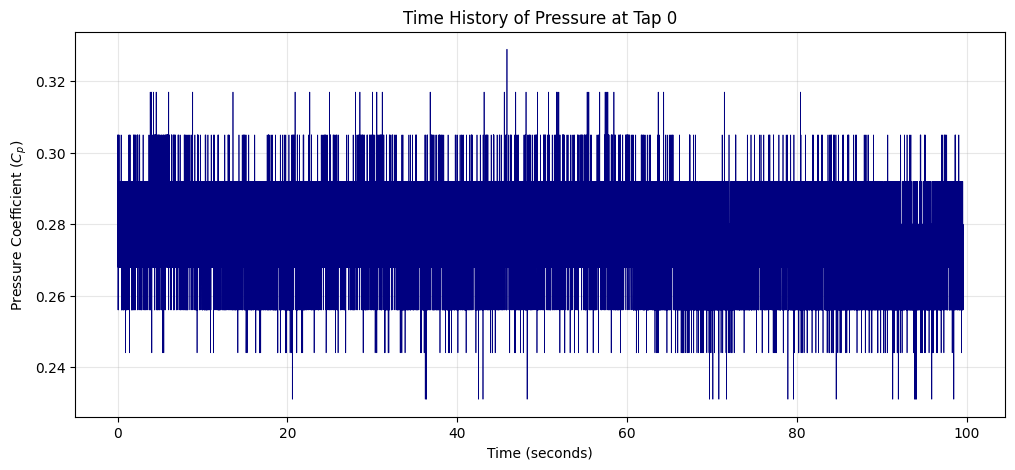

In [14]:
import numpy as np

# Define your sampling parameters
fs = 500  # Hz
dt = 1 / fs  # 0.002 seconds

# Create a time array that matches the length of your rows
# If df_pressures.shape[0] is 10,000, this creates 0.0 to 20.0 seconds
time_seconds = np.arange(len(df_asc)) * dt

# Now plot Tap 0 using actual time
plt.figure(figsize=(12, 5))
plt.plot(time_seconds, df_asc[0], color='navy', linewidth=0.5)

plt.title('Time History of Pressure at Tap 0')
plt.xlabel('Time (seconds)')
plt.ylabel('Pressure Coefficient ($C_p$)')
plt.grid(True, alpha=0.3)
plt.show()

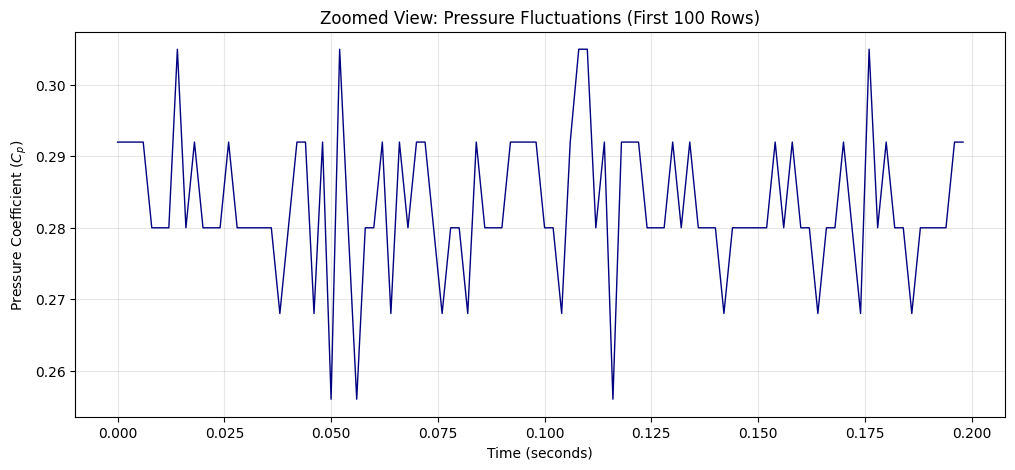

In [15]:
plt.figure(figsize=(12, 5))

# Plot only the first 1000 rows (2 seconds of data at 500Hz)
plt.plot(time_seconds[:100], df_asc[0][:100], color='navy', linewidth=1)

plt.title('Zoomed View: Pressure Fluctuations (First 100 Rows)')
plt.xlabel('Time (seconds)')
plt.ylabel('Pressure Coefficient ($C_p$)')
plt.grid(True, alpha=0.3)
plt.show()

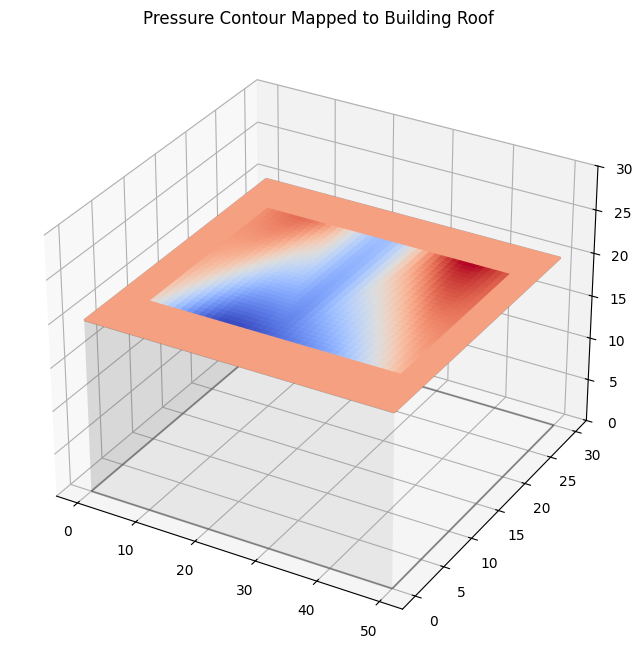

In [16]:
# --- STEP 1: Building Dimensions ---
length, width, height = 50, 30, 20  # Example dimensions in meters

# --- STEP 2: Your Tap Data (Placeholder - replace with your .asc row) ---
# Let's assume these taps are on the ROOF (Z = height)
x_taps = np.array([5, 15, 25, 35, 45, 5, 15, 25, 35, 45])
y_taps = np.array([5, 5, 5, 5, 5, 25, 25, 25, 25, 25])
pressures = np.random.uniform(-2, 1, size=len(x_taps)) # Replace with df_asc.iloc[0]

# --- STEP 3: Interpolation for the Contour ---
grid_x, grid_y = np.mgrid[0:length:50j, 0:width:50j]
grid_z_data = griddata((x_taps, y_taps), pressures, (grid_x, grid_y), method='cubic', fill_value=0)



fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- STEP 4: Draw the Building "Box" (Wireframe) ---
# Roof
X, Y = np.meshgrid([0, length], [0, width])
ax.plot_wireframe(X, Y, np.full_like(X, height), color='black', alpha=0.3)
# Base
ax.plot_wireframe(X, Y, np.zeros_like(X), color='black', alpha=0.3)

# --- STEP 5: Plot the Pressure Contour on the Roof ---
# We use the grid_z_data as the COLOR map, but the physical Z is the fixed 'height'
surf = ax.plot_surface(grid_x, grid_y, np.full_like(grid_x, height), 
                       facecolors=plt.cm.coolwarm((grid_z_data - grid_z_data.min()) / (grid_z_data.max() - grid_z_data.min())),
                       shade=False)

# --- STEP 6: Add the Walls ---
# Front wall (y=0)
X_w, Z_w = np.meshgrid([0, length], [0, height])
ax.plot_surface(X_w, np.zeros_like(X_w), Z_w, color='gray', alpha=0.1)
# side wall (x=0)
Y_w, Z_w = np.meshgrid([0, width], [0, height])
ax.plot_surface(np.zeros_like(Y_w), Y_w, Z_w, color='gray', alpha=0.1)

# --- Final touches ---
ax.set_zlim(0, height + 10)
plt.title("Pressure Contour Mapped to Building Roof")
plt.show()